In [ ]:
!pip install kaggle

In [ ]:
# Move & set permissions
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d rm1000/brain-tumor-mri-scans

Dataset URL: https://www.kaggle.com/datasets/rm1000/brain-tumor-mri-scans
License(s): CC0-1.0


In [ ]:
!unzip brain-tumor-mri-scans.zip -d brain_tumor_data

Streaming output truncated to the last 5000 lines.
  inflating: brain_tumor_data/healthy/0402.jpg  
  inflating: brain_tumor_data/healthy/0403.jpg  
  inflating: brain_tumor_data/healthy/0404.jpg  
  inflating: brain_tumor_data/healthy/0405.jpg  
  inflating: brain_tumor_data/healthy/0406.jpg  
  inflating: brain_tumor_data/healthy/0407.jpg  
  inflating: brain_tumor_data/healthy/0408.jpg  
  inflating: brain_tumor_data/healthy/0409.jpg  
  inflating: brain_tumor_data/healthy/0410.jpg  
  inflating: brain_tumor_data/healthy/0411.jpg  
  inflating: brain_tumor_data/healthy/0412.jpg  
  inflating: brain_tumor_data/healthy/0413.jpg  
  inflating: brain_tumor_data/healthy/0414.jpg  
  inflating: brain_tumor_data/healthy/0415.jpg  
  inflating: brain_tumor_data/healthy/0416.jpg  
  inflating: brain_tumor_data/healthy/0417.jpg  
  inflating: brain_tumor_data/healthy/0418.jpg  
  inflating: brain_tumor_data/healthy/0419.jpg  
  inflating: brain_tumor_data/healthy/0420.jpg  
  inflating: brain

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [ ]:
# Set dataset path
dataset_path = '/content/brain_tumor_data'
img_size = 128

# Initialize lists
data = []
labels = []

# Load, resize, and normalize images
for category in os.listdir(dataset_path):
    category_path = os.path.join(dataset_path, category)
    if not os.path.isdir(category_path):
        continue
    for file in os.listdir(category_path):
        file_path = os.path.join(category_path, file)
        try:
            image = Image.open(file_path).convert('L')  # Grayscale
            image = image.resize((img_size, img_size))
            image_array = np.array(image, dtype=np.float32) / 255.0  # Normalize
            data.append(image_array)
            labels.append(category)
        except Exception as e:
            print(f"Error reading {file_path}: {e}")

# Convert to arrays
X = np.array(data).reshape(-1, img_size, img_size, 1)
le = LabelEncoder()
y = to_categorical(le.fit_transform(labels))

print(f"Loaded {X.shape[0]} images")
print("Classes:", le.classes_)

Loaded 7023 images
Classes: ['glioma' 'healthy' 'meningioma' 'pituitary']


In [ ]:

from collections import defaultdict

# Define the dataset path
DATASET_PATH = '/content/brain_tumor_data'

# Function to describe each class by counting images and showing percentages
def describe_classes(root_dir):
    class_counts = defaultdict(int)

    # Walk through the directory and count images per class
    for dirpath, dirnames, filenames in os.walk(root_dir):
        class_name = os.path.basename(dirpath)
        for filename in filenames:
            if filename.lower().endswith('.jpg'):
                class_counts[class_name] += 1

    # Compute total number of images
    total_images = sum(class_counts.values())

    # Display class description with percentage
    print(f"\nTotal Images: {total_images}\n")
    print("Class Distribution:\n---------------------")
    for class_name, count in class_counts.items():
        percentage = (count / total_images) * 100
        print(f"Class: {class_name:<15} | Count: {count:<5} | Percentage: {percentage:.2f}%")

# Call the function
describe_classes(DATASET_PATH)








Total Images: 7023

Class Distribution:
---------------------
Class: glioma          | Count: 1621  | Percentage: 23.08%
Class: meningioma      | Count: 1645  | Percentage: 23.42%
Class: healthy         | Count: 2000  | Percentage: 28.48%
Class: pituitary       | Count: 1757  | Percentage: 25.02%


In [ ]:

# Set the path to your dataset
dataset_path = "/content/brain_tumor_data"

# Function to print folder structure and contents
def explore_dataset(path):
    for root, dirs, files in os.walk(path):
        print(f"Directory: {root}")
        print(f"Subdirectories: {dirs}")
        print(f"Files: {files}")
        print("-" * 40)

# Explore the dataset
explore_dataset(dataset_path)




Directory: /content/brain_tumor_data
Subdirectories: ['glioma', 'meningioma', 'healthy', 'pituitary']
Files: []
----------------------------------------
Directory: /content/brain_tumor_data/glioma
Subdirectories: []
Files: ['1231.jpg', '1074.jpg', '1118.jpg', '1554.jpg', '0306.jpg', '1296.jpg', '0278.jpg', '0233.jpg', '0951.jpg', '1197.jpg', '0104.jpg', '1156.jpg', '0827.jpg', '0309.jpg', '1553.jpg', '1587.jpg', '0396.jpg', '0015.jpg', '0616.jpg', '0249.jpg', '1386.jpg', '1566.jpg', '0456.jpg', '1023.jpg', '0022.jpg', '0199.jpg', '1031.jpg', '0412.jpg', '1149.jpg', '1317.jpg', '1235.jpg', '0835.jpg', '1182.jpg', '0231.jpg', '1006.jpg', '0111.jpg', '1105.jpg', '0717.jpg', '1069.jpg', '0621.jpg', '0619.jpg', '0447.jpg', '1606.jpg', '1455.jpg', '0189.jpg', '0350.jpg', '1402.jpg', '0637.jpg', '0033.jpg', '0869.jpg', '0320.jpg', '1016.jpg', '1595.jpg', '1158.jpg', '0385.jpg', '0927.jpg', '1420.jpg', '0765.jpg', '0490.jpg', '1187.jpg', '0415.jpg', '0117.jpg', '0739.jpg', '0821.jpg', '1469.jp

<ipython-input-9-82b743fbe26f>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=labels, palette='Set2')


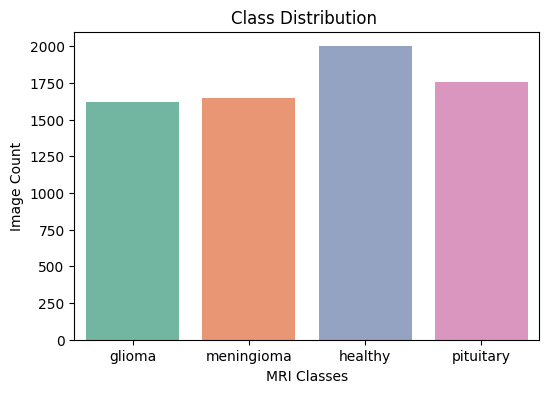

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x=labels, palette='Set2')
plt.title("Class Distribution ")
plt.xlabel("MRI Classes")
plt.ylabel("Image Count")
plt.show()






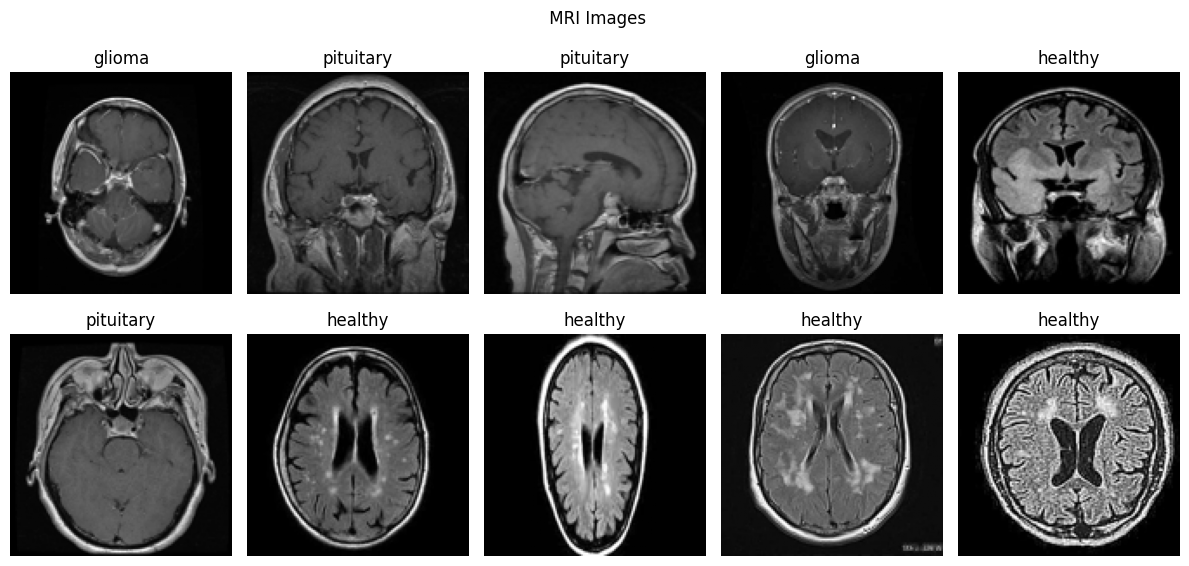

In [ ]:
plt.figure(figsize=(12, 6))
# Get the class names from the LabelEncoder used previously
class_names = le.classes_

for i in range(10):
    idx = np.random.randint(len(X))
    plt.subplot(2, 5, i+1)
    plt.imshow(X[idx].reshape(img_size, img_size), cmap='gray')
    # Get the index of the predicted class (highest probability in one-hot encoding)
    predicted_class_index = np.argmax(y[idx])
    plt.title(class_names[predicted_class_index])  # Use the index to access class name
    plt.axis('off')
plt.suptitle(" MRI Images")
plt.tight_layout()
plt.show()



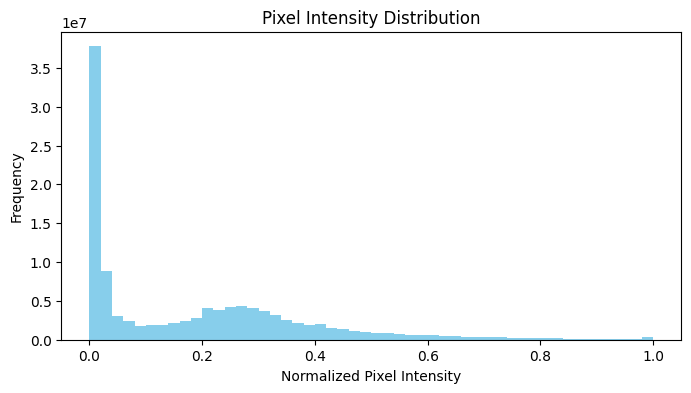

In [ ]:

plt.figure(figsize=(8, 4))
plt.hist(X.ravel(), bins=50, color='skyblue')
plt.title("Pixel Intensity Distribution")
plt.xlabel("Normalized Pixel Intensity")
plt.ylabel("Frequency")
plt.show()



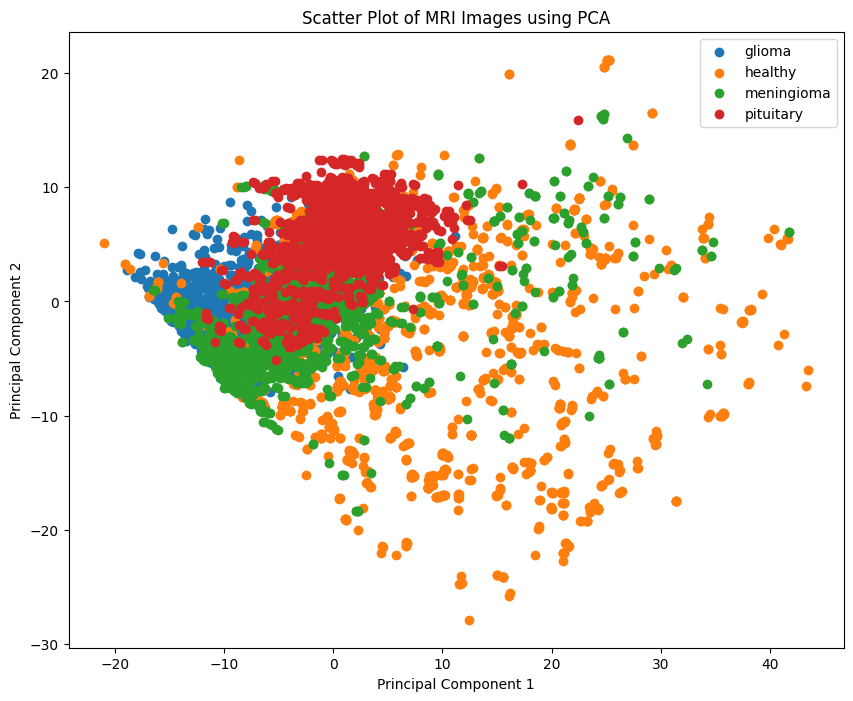

In [ ]:


# Reduce dimensionality using PCA for visualization
pca = PCA(n_components=2)  # Reduce to 2 components for a 2D scatter plot
X_pca = pca.fit_transform(X.reshape(X.shape[0], -1))

# Create the scatter plot
plt.figure(figsize=(10, 8))
for i in range(len(le.classes_)):
    plt.scatter(X_pca[np.where(np.argmax(y, axis=1) == i), 0],
                X_pca[np.where(np.argmax(y, axis=1) == i), 1],
                label=le.classes_[i])

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Scatter Plot of MRI Images using PCA")
plt.legend()
plt.show()

<ipython-input-15-97bebb824a18>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=predicted_class_labels, y=avg_intensity, palette='Set3')


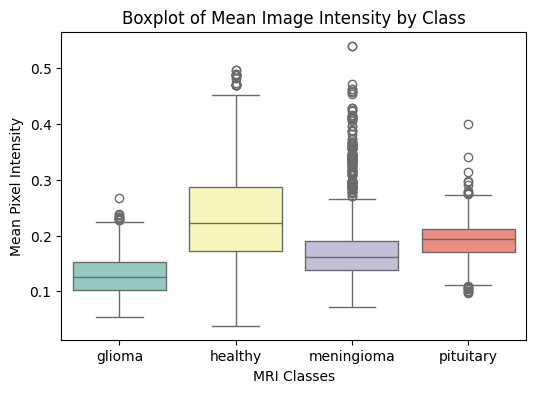

In [ ]:
avg_intensity = np.mean(X.reshape(len(X), -1), axis=1)

plt.figure(figsize=(6, 4))
# Get the predicted class labels from the one-hot encoded labels
predicted_class_labels = np.argmax(y, axis=1)
# Use predicted class labels for x-axis
sns.boxplot(x=predicted_class_labels, y=avg_intensity, palette='Set3')
plt.xticks([0, 1, 2, 3], class_names)  # Adjust xticks for all classes
plt.title("Boxplot of Mean Image Intensity by Class")
plt.xlabel("MRI Classes")
plt.ylabel("Mean Pixel Intensity")
plt.show()



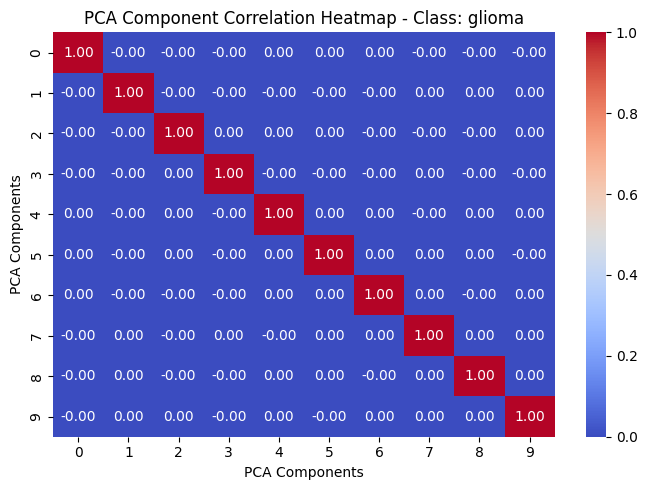

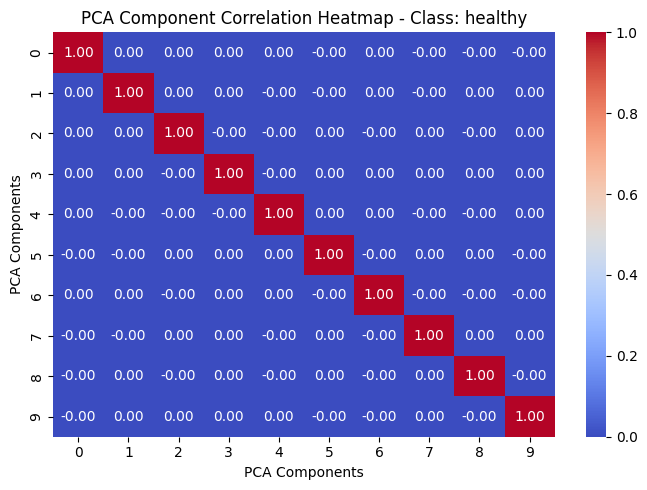

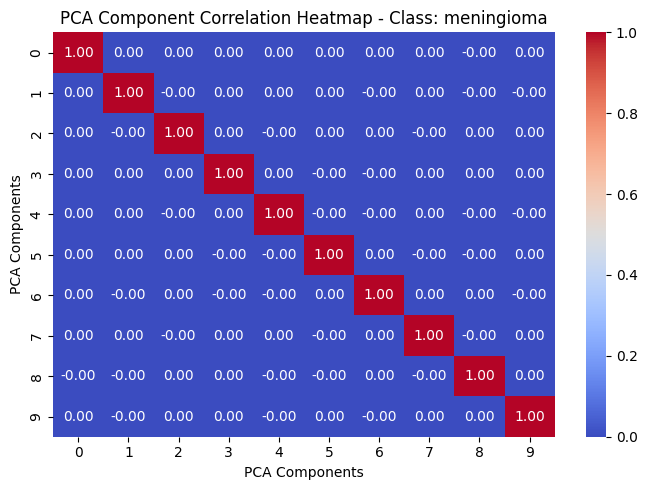

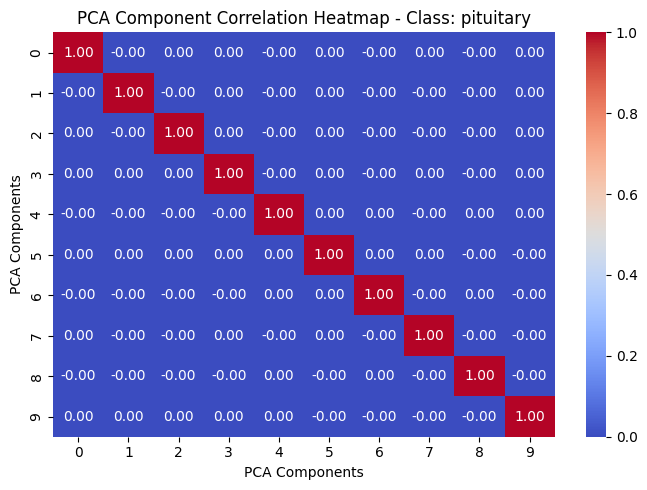

In [ ]:


# Flatten the image data
X_flat = X.reshape(len(X), -1)

# Convert to dictionary by class
class_pca = {}
num_components = 10

# Get the predicted class labels from the one-hot encoded labels
predicted_class_labels = np.argmax(y, axis=1)

for class_index, class_name in enumerate(class_names):
    # Get samples of this class using predicted class labels
    X_class = X_flat[predicted_class_labels == class_index]

    # Apply PCA
    pca = PCA(n_components=num_components)
    X_class_pca = pca.fit_transform(X_class)

    # Store PCA-transformed data
    class_pca[class_name] = X_class_pca

    # Plot heatmap
    plt.figure(figsize=(7, 5))
    sns.heatmap(np.corrcoef(X_class_pca.T), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title(f"PCA Component Correlation Heatmap - Class: {class_name}")
    plt.xlabel("PCA Components")
    plt.ylabel("PCA Components")
    plt.tight_layout()
    plt.show()


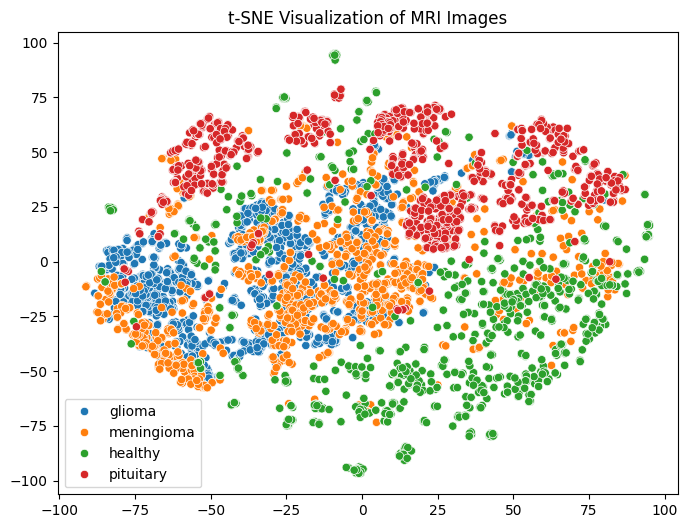

In [ ]:


X_flat = X.reshape(X.shape[0], -1)  # Flatten images

# Use PCA for faster t-SNE
pca = PCA(n_components=50).fit_transform(X_flat)
tsne = TSNE(n_components=2, perplexity=30).fit_transform(pca)

# Plot t-SNE
plt.figure(figsize=(8, 6))
sns.scatterplot(x=tsne[:, 0], y=tsne[:, 1], hue=le.inverse_transform(np.argmax(y, axis=1)))
plt.title("t-SNE Visualization of MRI Images")
plt.show()

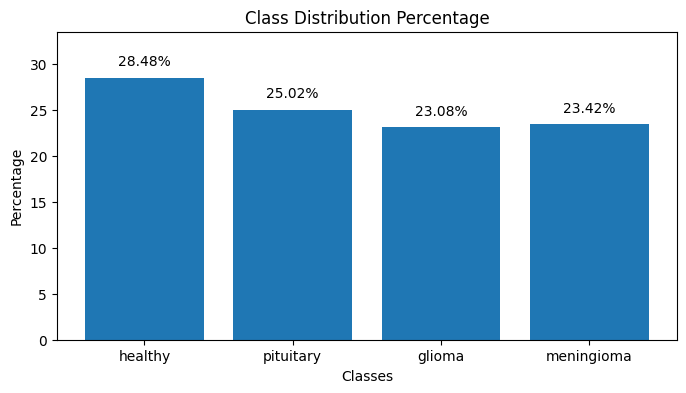

In [ ]:
class_percentages = {'healthy':28.48, 'pituitary':25.02, 'glioma':23.08,'meningioma':23.42}


plt.figure(figsize=(8, 4))
bars = plt.bar(class_percentages.keys(), class_percentages.values())
plt.title('Class Distribution Percentage')
plt.xlabel('Classes')
plt.ylabel('Percentage')

# Add percentage labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.2f}%', ha='center', va='bottom')
plt.ylim(0, max(class_percentages.values()) + 5)
plt.show()